In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset procesado
df = pd.read_csv("../data/processed/reviews_en_clean.csv")

# 2. Convertir marcas de tiempo a datetime
# (timestamp_created suele estar en formato epoch/unix en segundos)
if 'timestamp_created' in df.columns:
    df['date'] = pd.to_datetime(df['timestamp_created'], unit='s')
elif 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

df['day'] = df['date'].dt.date

# 3. Vista rápida de la distribución temporal
print(f"Rango de fechas: desde {df['day'].min()} hasta {df['day'].max()}")
print(f"Total de registros a evaluar: {len(df):,}")

Rango de fechas: desde 2015-05-18 hasta 2021-01-23
Total de registros a evaluar: 166,191


In [4]:
# 1. Verificar qué columnas tenemos disponibles
print("Columnas en el DataFrame:", df.columns.tolist())

# 2. Asegurar que recommended sea numérico/booleano para contar votos
if df['recommended'].dtype == 'bool':
    df['is_negative'] = (~df['recommended']).astype(int)
    df['is_positive'] = df['recommended'].astype(int)
else:
    df['is_negative'] = (df['recommended'] == 0).astype(int)
    df['is_positive'] = (df['recommended'] == 1).astype(int)

# 3. Agregación temporal por día
daily_stats = df.groupby('day').agg(
    total_reviews=('is_negative', 'count'),
    negative_reviews=('is_negative', 'sum'),
    positive_reviews=('is_positive', 'sum')
).reset_index()

# 4. Calcular ratio de negatividad diario
daily_stats['negative_ratio'] = daily_stats['negative_reviews'] / daily_stats['total_reviews']
daily_stats['day'] = pd.to_datetime(daily_stats['day'])

daily_stats.head(10)

Columnas en el DataFrame: ['Unnamed: 0', 'app_id', 'app_name', 'review_id', 'language', 'review', 'timestamp_created', 'timestamp_updated', 'recommended', 'votes_helpful', 'votes_funny', 'weighted_vote_score', 'comment_count', 'steam_purchase', 'received_for_free', 'written_during_early_access', 'author.steamid', 'author.num_games_owned', 'author.num_reviews', 'author.playtime_forever', 'author.playtime_last_two_weeks', 'author.playtime_at_review', 'author.last_played', 'word_count', 'date', 'day']


,day,total_reviews,negative_reviews,positive_reviews,negative_ratio
0,2015-05-18,51,6,45,0.117647
1,2015-05-19,766,39,727,0.050914
2,2015-05-20,433,20,413,0.046189
3,2015-05-21,288,12,276,0.041667
4,2015-05-22,258,10,248,0.038760
5,2015-05-23,245,8,237,0.032653
6,2015-05-24,258,13,245,0.050388
7,2015-05-25,310,4,306,0.012903
8,2015-05-26,267,11,256,0.041199
9,2015-05-27,229,6,223,0.026201


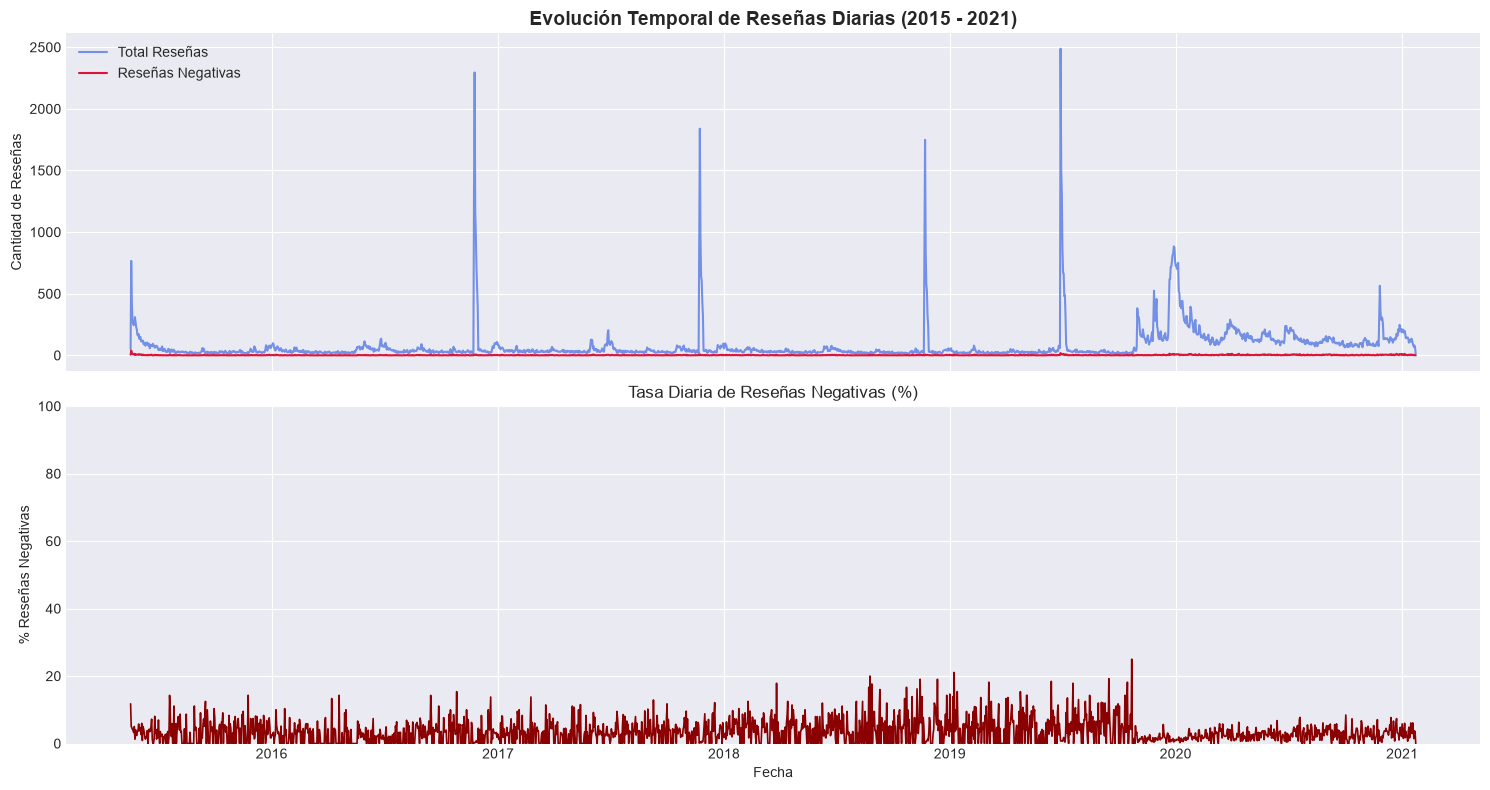

In [5]:
plt.style.use('seaborn-v0_8-darkgrid' if 'seaborn-v0_8-darkgrid' in plt.style.available else 'default')
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8), sharex=True)

# 1. Volumen total vs Reseñas Negativas
ax1.plot(daily_stats['day'], daily_stats['total_reviews'], label='Total Reseñas', color='royalblue', alpha=0.7)
ax1.plot(daily_stats['day'], daily_stats['negative_reviews'], label='Reseñas Negativas', color='crimson', linewidth=1.5)
ax1.set_ylabel("Cantidad de Reseñas")
ax1.set_title("Evolución Temporal de Reseñas Diarias (2015 - 2021)", fontsize=14, fontweight='bold')
ax1.legend(loc="upper left")

# 2. Tasa de Negatividad Diaria
ax2.plot(daily_stats['day'], daily_stats['negative_ratio'] * 100, color='darkred', linewidth=1.2)
ax2.set_ylabel("% Reseñas Negativas")
ax2.set_xlabel("Fecha")
ax2.set_title("Tasa Diaria de Reseñas Negativas (%)", fontsize=12)
ax2.set_ylim(0, 100)

plt.tight_layout()
plt.show()

## Análisis Visual de Series Temporales (2015 - 2021)

### 1. Picos Puntuales de Volumen (2016, 2017, 2018 y mediados de 2019)
* **Comportamiento observado:** Se registran picos aislados de alta intensidad con volúmenes diarios superiores a 1.700 - 2.500 reseñas.
* **Diagnóstico preliminar:** La cantidad absoluta de reseñas negativas se mantiene insignificante durante estos eventos. Esto indica que los picos podrian estar asociados a eventos promocionales externos (rebajas de temporada de Steam, periodos gratuitos o nominaciones) y no a ataques coordinados de descontento al ver que el numero de reseñas negativas no crece.

### 2. Régimen Continuo (2019 - 2020)
* **Comportamiento observado:** A finales de 2019 se produce un aumento sostenido en el volumen base diario (500 - 1.000 reseñas por día) que se prolonga durante meses antes de estabilizarse.
* **Diagnóstico preliminar:** Corresponde a una expansión estructural de la base de jugadores, potencialmente vinculada a expansiones de contenido o factores externos como la pandemia iniciada en 2020.

### 3. Dinámica de la Tasa Diaria de Negatividad
* **Periodo 2015 - Mediados 2019:** El porcentaje diario de quejas presenta alta volatilidad, oscilando habitualmente entre 5% y 20%.
* **Periodo Finales 2019 - 2021:** Se observa una reducción notable en la dispersión de quejas, estabilizándose por debajo del 5% diario. Sugiere estabilización técnica del título y consolidación de una recepción predominantemente positiva.

## Metodología de Detección de Anomalías: Rolling Z-Score

Para identificar matemáticamente eventos de descontento coordinado o atípico (*Review Bombing*), se implementa un detector basado en **Rolling Z-Score** sobre ventanas móviles de 14 días:

$$Z_t = \frac{R_t - \mu_{14}}{\sigma_{14} + \epsilon}$$

Donde:
* $R_t$: Tasa de negatividad del día evaluado ($t$).
* $\mu_{14}$: Media móvil de la tasa de negatividad en los últimos 14 días.
* $\sigma_{14}$: Desviación estándar móvil de los últimos 14 días.
* $\epsilon$: Término de suavizado ($10^{-6}$) para evitar divisiones por cero.

In [15]:
# 1. Métricas base por juego para calibración dinámica
game_baselines = game_daily_stats.groupby('app_name').agg(
    median_daily_reviews=('total_reviews', 'median'),
    mean_negative_ratio=('negative_ratio', 'mean'),
    std_negative_ratio=('negative_ratio', 'std')
).reset_index()

print("Líneas de base calculadas por juego:")
print(game_baselines)

# 2. Unir métricas de base para evaluar de forma relativa
game_daily_stats = game_daily_stats.merge(game_baselines, on='app_name', how='left')

# 3. Criterio Estadístico Formal (99% de confianza, volumen > mediana, ratio > 2x promedio)
game_daily_stats['is_bombing_stat'] = (
    (game_daily_stats['z_score'] > 2.576) & 
    (game_daily_stats['total_reviews'] >= game_daily_stats['median_daily_reviews']) &
    (game_daily_stats['negative_ratio'] > (2 * game_daily_stats['mean_negative_ratio']))
)

objective_anomalies = game_daily_stats[game_daily_stats['is_bombing_stat']]
print(f"\nTotal de eventos anómalos detectados: {len(objective_anomalies)}")
objective_anomalies[['app_name', 'day', 'total_reviews', 'negative_reviews', 'negative_ratio', 'z_score']].sort_values(by=['app_name', 'z_score'], ascending=[True, False])

Líneas de base calculadas por juego:
                   app_name  median_daily_reviews  mean_negative_ratio  \
0                 Half-Life                  19.0             0.044084   
1  The Witcher 3: Wild Hunt                  35.0             0.033526   

   std_negative_ratio  
0            0.080312  
1            0.035073  

Total de eventos anómalos detectados: 6


,app_name,day,total_reviews,negative_reviews,negative_ratio,z_score
258,Half-Life,2019-12-12,19,3,0.157895,2.841378
726,The Witcher 3: Wild Hunt,2015-07-20,42,6,0.142857,3.249225
1334,The Witcher 3: Wild Hunt,2017-03-19,35,4,0.114286,2.899684
1230,The Witcher 3: Wild Hunt,2016-12-05,36,3,0.083333,2.731774
2678,The Witcher 3: Wild Hunt,2020-11-22,92,8,0.086957,2.717372
2627,The Witcher 3: Wild Hunt,2020-10-02,58,5,0.086207,2.623676


In [18]:
# 1. Homogeneizar tipos de datos para la columna 'day'
df['day'] = pd.to_datetime(df['day'])
game_daily_stats['day'] = pd.to_datetime(game_daily_stats['day'])

# 2. Unir el flag objetivo al DataFrame original
df_merged = df.merge(
    game_daily_stats[['app_name', 'day', 'is_bombing_stat']], 
    on=['app_name', 'day'], 
    how='left'
)

# 3. Localizar columna de horas jugadas (ej. author_playtime_forever o playtime_forever)
playtime_col = [col for col in df.columns if 'playtime' in col.lower()]

if playtime_col:
    # Usamos la primera columna de tiempo encontrada
    target_col = playtime_col[0]
    
    # En Steam los registros suelen estar en minutos; convertimos a horas
    df_merged['hours_played'] = df_merged[target_col] / 60.0
    
    # 4. Filtrar únicamente las reseñas negativas
    neg_reviews = df_merged[df_merged['is_negative'] == 1]
    
    # 5. Comparativa de horas jugadas: Días normales vs Días anómalos
    behavior_analysis = neg_reviews.groupby(['app_name', 'is_bombing_stat'])['hours_played'].agg(
        cantidad_reviews='count',
        mediana_horas=('median'),
        promedio_horas=('mean')
    ).reset_index()
    
    behavior_analysis['tipo_periodo'] = behavior_analysis['is_bombing_stat'].map(
        {True: 'Día de Anomalía (Posible Bombing)', False: 'Día Normal'}
    )
    
    print("\n--- COMPARATIVA DE HORAS JUGADAS EN QUEJAS ---")
    display(behavior_analysis[['app_name', 'tipo_periodo', 'cantidad_reviews', 'mediana_horas', 'promedio_horas']])


--- COMPARATIVA DE HORAS JUGADAS EN QUEJAS ---


,app_name,tipo_periodo,cantidad_reviews,mediana_horas,promedio_horas
0,Half-Life,Día Normal,555,9.433333,18.429369
1,Half-Life,Día de Anomalía (Posible Bombing),3,7.200000,8.083333
2,The Witcher 3: Wild Hunt,Día Normal,3499,18.350000,63.925036
3,The Witcher 3: Wild Hunt,Día de Anomalía (Posible Bombing),26,20.833333,50.462821


## Conclusiones del análisis de anomalías 

### 1. Eventos críticos identificados
* Se detectaron un total de **6 fechas con anomalía estadística significativa** ($Z > 2.576$, significancia $\alpha = 0.01$):
  * **Half-Life:** 1 evento (2019-12-12, $Z = 2.84$, 15.79% quejas).
  * **The Witcher 3:** 5 eventos (pico máximo el 2015-07-20 con $Z = 3.25$ y 14.29% de quejas).

### 2. Validación de Hipótesis: ¿Review bombing o queja legítima?
* **Half-Life:** Se observa una reducción en el promedio de tiempo jugado durante el pico anómalo ($8.08\text{ hs}$ vs $18.43\text{ hs}$ en régimen normal), indicando una mayor concentración de usuarios casuales o votos de descontento rápido. Por ser ademas tan pocas reseñas negativas, incluso para un dia anómalo, parecen ser quejas legitimas de usuarios.
* **The Witcher 3:** La mediana de horas jugadas en las fechas anómalas ($20.83\text{ hs}$) es superior a la de los periodos estándar ($18.35\text{ hs}$). Esto demuestra que los picos de negatividad no respondieron a campañas de boicot con cuentas ficticias o tiempos mínimos de juego, sino a descontento operativo genuino de usuarios activos con alta dedicación horaria. Por lo cual esto tampoco se podria considerar episodios de review bombing.